In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import FormatStrFormatter
from matplotlib import gridspec
%matplotlib inline

In [2]:
SMALL_SIZE = 10
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [ ]:
file_list = [
    'P2_rg.xvg',
    'P3_rg.xvg'
]

1.242 1.408885591740826
1.865 2.1120635561443857


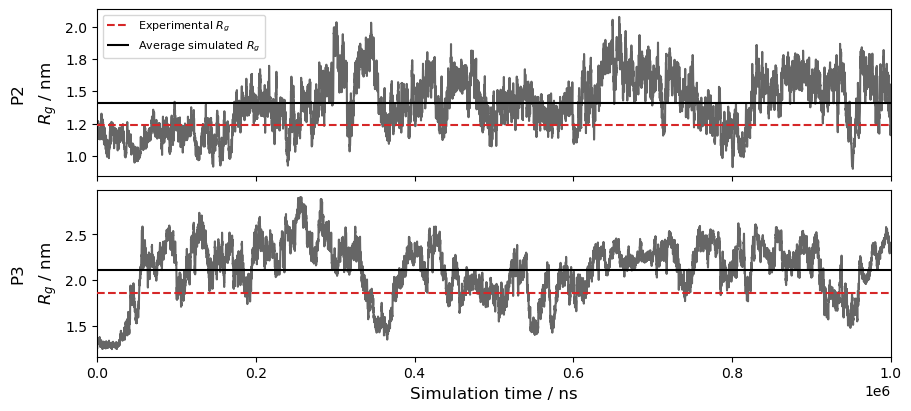

In [4]:
fig, ax = plt.subplot_mosaic([['a', 'a'],
                               ['b', 'b']],
                              figsize=(9, 4),
                              sharex=True,
                              layout="constrained")

subplot_list = ['a','b']
exp_rg_list = [1.242, 1.865] 
text_list = ['P2', 'P3']
for i,j,exprg,textstr in zip(file_list,subplot_list, exp_rg_list,text_list):
    data = np.loadtxt(i, comments=('#', '@'), usecols=(0,1))
    #rg, rg_err = parse_stat('LPMO_theta{}_rg.stat'.format(j))
    ax[j].set_ylabel('$R_g$ / nm')
    ax[j].plot(data[:,0]-data[:,0][0], data[:,1], 'k-', alpha=0.6)
    ax[j].hlines(exprg,0,1e6,'tab:red', linestyles='dashed', zorder=10, label='Experimental $R_g$')
    calcrg = np.mean(data[:,1])
    print(exprg, calcrg)
    ax[j].hlines(calcrg,0,1e6,'black', zorder=10, label='Average simulated $R_g$')
    ymin, ymax = ax[j].get_ylim()
    ax[j].text(-0.11e6, (ymin+ymax)*0.5, textstr, verticalalignment='center', rotation=90, fontsize=MEDIUM_SIZE)
    ax[j].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))


    #data = np.loadtxt('LPMO_theta{}_dist.xvg'.format(j), comments=('#', '@'), usecols=(0,1))
    #dist, dist_err = parse_stat('LPMO_theta{}_dist.stat'.format(j))

    #ax[i,1].set_ylabel('ID / nm')
    #ax[i,1].plot(data[:,0]-data[:,0][0], data[:,1], 'k-', alpha=0.6)
    #ax[i,1].hlines(dist,0,1e7,'black', zorder=10, label='Average simulated ID')

ax['a'].legend(fontsize=8)

#ax[0,1].legend()
ax['b'].set_xlim(0,1e6)
ax['b'].set_xlabel('Simulation time / ns')
#ax[4,1].set_xlabel('Simulation time / ns')
plt.savefig('md_plots.png', dpi=300)
plt.show()